# Repetition Lag-CRP

> Separate temporal contiguity curves by presentation index for repeated items.

The repetition Lag-CRP extends the standard Lag-CRP analysis to study lists containing repeated items. For each recall of a repeated item, the analysis separately tabulates lag transitions relative to each of the item's study positions. This produces one CRP curve per presentation index, revealing whether transitions from repeated items cluster around the first or second occurrence.

Comparing repetition CRP curves between observed data and shuffled controls helps isolate repetition-specific effects from baseline temporal contiguity.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.repcrp import (
    plot_rep_crp,
    subject_rep_crp,
    test_first_second_bias,
    test_rep_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, 0.3]
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


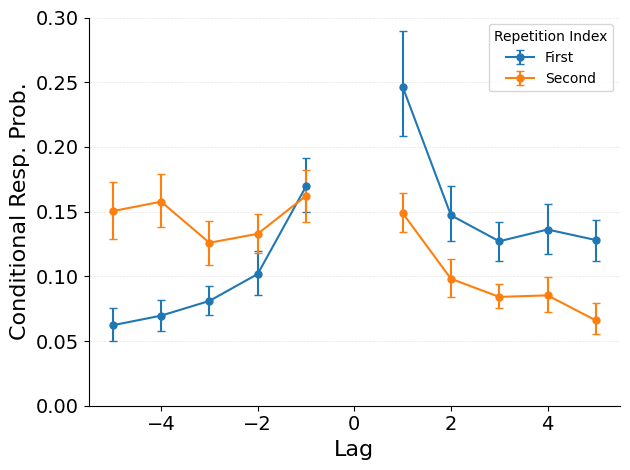

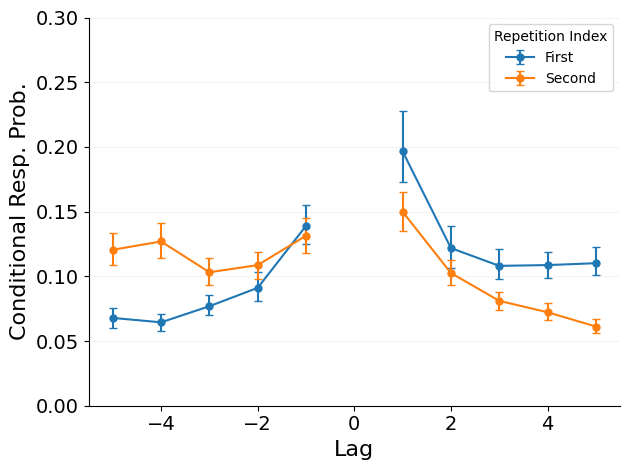

In [4]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")

In [5]:
observed_crp = subject_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)

bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print(bias_result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |   -0.732     0.4689 |    249.0     0.2872 |    -0.0056
   -4 |    0.771     0.4463 |    262.0     0.3945 |     0.0052
   -3 |    0.626     0.5355 |    281.0     0.5876 |     0.0041
   -2 |    1.382     0.1759 |    259.0     0.3678 |     0.0107
   -1 |    3.465     0.0015 |    127.0     0.0015 |     0.0305
    0 |      nan        nan |      nan        nan |        nan
    1 |    3.787     0.0006 |    116.0     0.0007 |     0.0500
    2 |    2.635     0.0126 |    172.0     0.0182 |     0.0253
    3 |    2.697     0.0108 |    168.0     0.0151 |     0.0190
    4 |    3.155     0.0034 |    131.0     0.0020 |     0.0275
    5 |    2.057     0.0474 |    212.0     0.0934 |     0.0179

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/repcrp.py:592: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/repcrp.py:603: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/repcrp.py:660: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/repcrp.py:671: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)


## Interpretation

Two plots are produced: one for observed (mixed-list) data and one for the shuffled control. Each plot shows separate CRP curves for transitions relative to the first and second presentation of repeated items. Key patterns:

- **First vs. second presentation bias**: if one presentation's curve is consistently higher, participants preferentially transition relative to that occurrence.
- **Observed vs. control**: differences between observed and control curves isolate repetition-specific contiguity beyond what shuffled position assignments would produce.
- **Statistical tests**: the t-tests and Wilcoxon tests quantify whether the observed repetition CRP reliably exceeds the control at each lag.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a list, or `None` for automatic scaling.
- `mixed_trial_query` — query selecting trials with repeated items.
- `control_trial_query` — query selecting trials for the control (typically non-repeating lists).
- `control_shuffles` — number of shuffle iterations for building the control dataset.
- `min_lag` — minimum absolute lag included in the analysis.
- `max_lag` — maximum absolute lag displayed.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.